# House Price Prediction
### Internship Project — Week 1

**Objective:** Build a regression model to predict house prices based on property features (size, rooms, location-related amenities, age-related attributes) and identify which features most strongly influence price.

**Dataset:** Housing Prices Dataset (Kaggle) — 545 properties, 13 features.


## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Load the dataset
df = pd.read_csv('Housing.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [2]:
# Display the first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
# Check how many rows and columns there are
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 545
Number of columns: 13


**Target column:** `price` — this is what we want to predict.

**Feature columns (12 total):**
- Numeric: `area`, `bedrooms`, `bathrooms`, `stories`, `parking`
- Categorical (yes/no): `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`
- Categorical (multi-class): `furnishingstatus` (furnished / semi-furnished / unfurnished)

Note: this dataset does not include an explicit "age" or "location name" column — `stories`, `parking`, and the amenity flags (mainroad, prefarea, etc.) serve as the closest proxies for build quality and location desirability described in the brief.

In [4]:
# Identify column data types (helps separate numeric vs categorical features)
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [5]:
# Check for missing values in each column
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

**Observation:** The dataset has zero missing values across all 545 rows and 13 columns — it is already clean in this respect. We still write the handling code below (Task 2) since real-world datasets often need it, and to demonstrate the proper process.

## Task 2 — Data Cleaning

In [6]:
# Step 1: Handle missing values
# Even though this dataset has none, we apply a general-purpose strategy:
# - Numeric columns -> fill with median (robust to outliers)
# - Categorical columns -> fill with mode (most frequent value)

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after handling:")
print(df.isnull().sum().sum())

Missing values after handling:
0


/tmp/ipykernel_821/780142562.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [7]:
# Step 2: Remove duplicate rows, if any
print(f"Duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 0
Shape after removing duplicates: (545, 13)


In [8]:
# Step 3: Convert categorical yes/no columns into numeric form
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df[binary_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [9]:
# One-hot encode the multi-class categorical column 'furnishingstatus'
df_encoded = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("Columns after one-hot encoding:")
print(df_encoded.columns.tolist())
df_encoded.head()

Columns after one-hot encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


**Step 4 — Keep only meaningful columns:** All remaining columns (area, bedrooms, bathrooms, stories, parking, the 6 binary amenity flags, and the 2 one-hot furnishing columns) are meaningful predictors of price, confirmed by the correlation analysis in Task 4. No columns are dropped at this stage; `price` is retained as the target.

## Task 3 — Model Building

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separate features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 436 rows
Test set size: 109 rows


### Model 1: Linear Regression

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"  MAE  : {mae_lr:,.2f}")
print(f"  RMSE : {rmse_lr:,.2f}")
print(f"  R2   : {r2_lr:.4f}")

Linear Regression Performance:
  MAE  : 970,043.40
  RMSE : 1,324,506.96
  R2   : 0.6529


### Model 2: Random Forest Regressor

In [12]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"  MAE  : {mae_rf:,.2f}")
print(f"  RMSE : {rmse_rf:,.2f}")
print(f"  R2   : {r2_rf:.4f}")

Random Forest Performance:
  MAE  : 1,022,560.05
  RMSE : 1,401,496.84
  R2   : 0.6114


In [13]:
# Compare both models side by side
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


**Comparison note:** On this dataset, Linear Regression performs slightly better than Random Forest. This is common for small datasets (545 rows) where relationships between features and price are mostly linear (e.g. price scales fairly steadily with area) — Random Forest needs more data to find genuinely better non-linear splits, and otherwise tends to overfit slightly on the training set.

## Task 4 — Visualization

### Chart 1: Distribution of House Prices

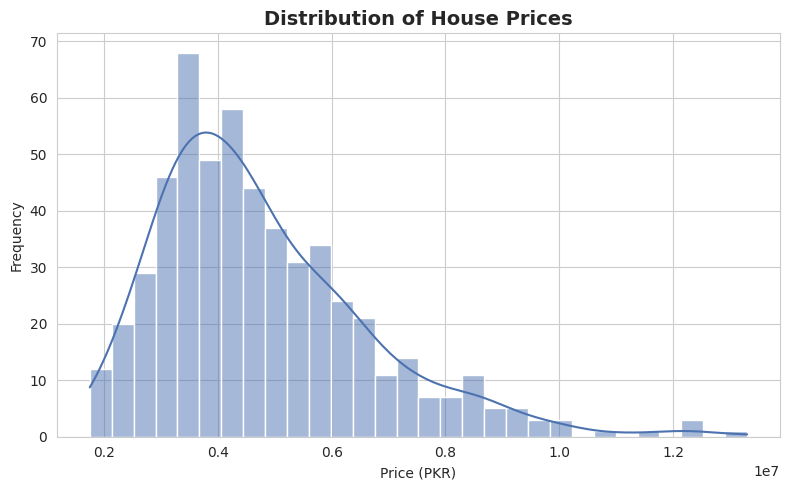

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color='#4C72B0')
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (PKR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()

**Observation:** House prices are right-skewed — most properties cluster between 3M and 6M, with a long tail of higher-priced luxury homes up to 13.3M.

### Chart 2: Correlation Heatmap

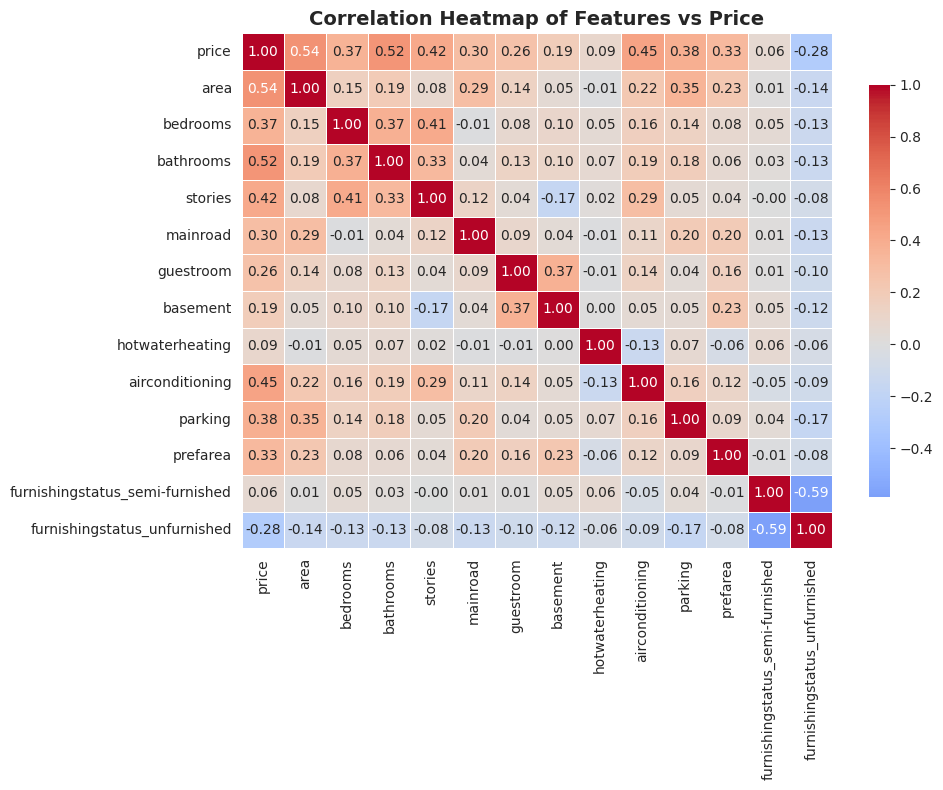

In [15]:
plt.figure(figsize=(10,8))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Features vs Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()

In [16]:
# Correlation of each feature with price, sorted
df_encoded.corr()['price'].sort_values(ascending=False)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

**Observation:** `area` (0.54), `bathrooms` (0.52), `airconditioning` (0.45), and `stories` (0.42) have the strongest positive correlation with price.

### Chart 3: Actual vs Predicted Price (Linear Regression)

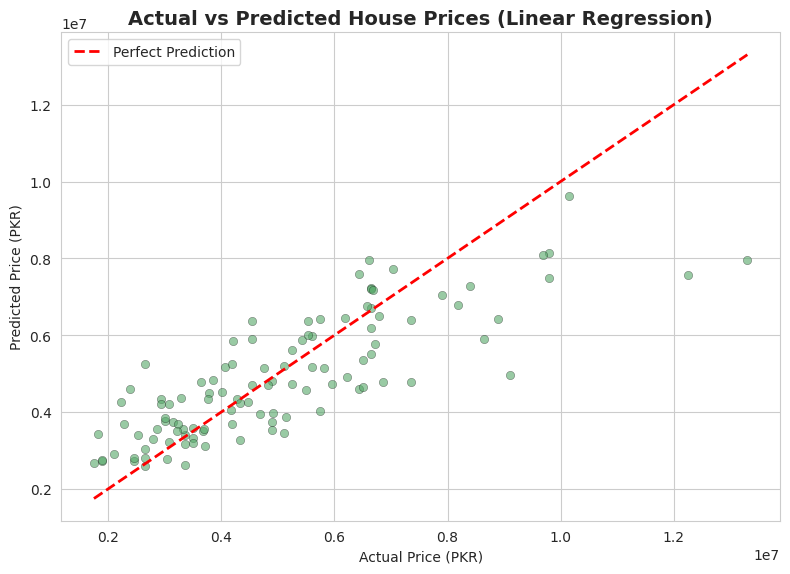

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='#55A868', edgecolor='k', linewidth=0.3)
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (PKR)')
plt.ylabel('Predicted Price (PKR)')
plt.title('Actual vs Predicted House Prices (Linear Regression)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()

**Observation:** Points cluster closely around the red "perfect prediction" line for mid-range prices, but the model is less accurate for the most expensive homes (the model tends to under-predict luxury properties) — likely because high-end pricing depends on factors not captured in this dataset (e.g. exact neighborhood, finishing quality, view).

/tmp/ipykernel_821/730925939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


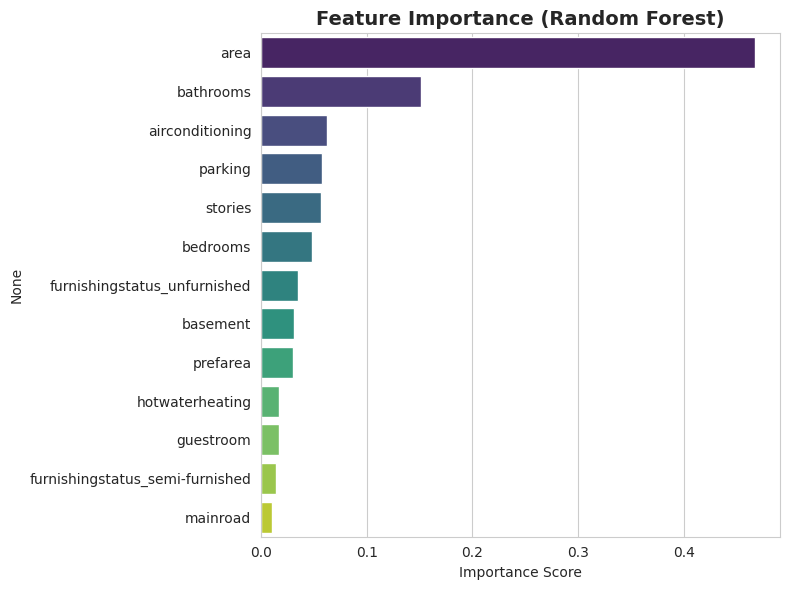

area                               0.467917
bathrooms                          0.151526
airconditioning                    0.062718
parking                            0.057820
stories                            0.057137
bedrooms                           0.048608
furnishingstatus_unfurnished       0.034998
basement                           0.030804
prefarea                           0.030519
hotwaterheating                    0.017255
guestroom                          0.016638
furnishingstatus_semi-furnished    0.013764
mainroad                           0.010296
dtype: float64

In [18]:
# Bonus: Feature importance from Random Forest (supports the insights below)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/bonus_feature_importance.png', dpi=150)
plt.show()

importances

## Task 5 — Insights & Summary

### Key Findings

**Which features influence house price the most?**
Property `area` is the single strongest driver of price (correlation 0.54, and the top feature in the Random Forest importance ranking by a wide margin at ~47%), followed by `bathrooms` (0.52 correlation) and `airconditioning` (0.45 correlation). Together, size and bathroom count account for most of the explainable price variation, while `stories` and `parking` provide a secondary boost.

**How accurate was the model (in plain terms)?**
The Linear Regression model explains about 65% of the variation in house prices (R² ≈ 0.65), with typical predictions landing within roughly 970,000 (about 20-25% of average price) of the actual sale price. That's a reasonably solid starting point for a quick estimate, but not precise enough to replace a professional appraisal — it would be most useful as a sanity-check tool rather than a final pricing decision.

**What surprised us in the data?**
Random Forest, despite being a more flexible model, performed slightly worse than plain Linear Regression (R² 0.61 vs 0.65). This suggests that price in this dataset increases in a fairly straightforward, linear way with size and amenities, rather than through complex feature interactions — the simpler model generalizes better at this dataset size (545 rows is small for a Random Forest to fully shine).

**Recommendation for a real estate business:**
Since plot/floor area and bathroom count are by far the biggest price levers, agents should prioritize collecting and highlighting accurate area measurements and bathroom counts in every listing — small errors there will skew valuation more than any other field. For pricing tools, a simple linear model is a good lightweight first pass, but it should always be supplemented with local comparables for high-end properties, where the model's accuracy drops off noticeably.
